<a href="https://colab.research.google.com/github/shahabafshar/ML-AG-BIO-01/blob/main/HW3/HW3_ME_5920_Data_Analytics_and_ML_for_CPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data was downloaded, merged and then down sampled to 480 wide mp4s usinig ffmpeg. Then the data was split into training and testing (8/20). Randomly sampled images were also down sampled : def extract_random_frame(video_path, image_size=(112, 112)):
    cap = cv2.VideoCapture(video_path) -- see supplementary code

#4 Frame set up and loaders

In [2]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ============================================================
# USER SETTINGS
# ============================================================
# Update this path if the folder is nested deeper in your Drive
data_root = "/content/drive/MyDrive/Colab Notebooks/Sheep_Frames_4"
batch_size = 32          # edit this
num_workers = 2          # Increased for Colab's Linux environment
image_size = 112         # fixed input size for all images

# ============================================================
# DEVICE
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# IMAGE PREPROCESSING
# ============================================================
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ============================================================
# LOAD TRAIN AND TEST IMAGE DATASETS
# ============================================================
train_dataset = datasets.ImageFolder(
    root=os.path.join(data_root, "train"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(data_root, "test"),
    transform=transform
)

# ============================================================
# CREATE DATALOADERS
# ============================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

print("Class names:", train_dataset.classes)
print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
Class names: ['grazing', 'running', 'sitting', 'standing', 'walking']
Train images: 1308
Test images: 328


Training

Class counts: [288, 200, 316, 352, 152]
Class weights: tensor([0.9083, 1.3080, 0.8278, 0.7432, 1.7211])
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 110MB/s]


Epoch [1/10] - Loss: 0.5374 - Train Acc: 0.8050
Epoch [2/10] - Loss: 0.1587 - Train Acc: 0.9526
Epoch [3/10] - Loss: 0.0963 - Train Acc: 0.9709
Epoch [4/10] - Loss: 0.0827 - Train Acc: 0.9817
Epoch [5/10] - Loss: 0.0489 - Train Acc: 0.9847
Epoch [6/10] - Loss: 0.0295 - Train Acc: 0.9908
Epoch [7/10] - Loss: 0.0666 - Train Acc: 0.9839
Epoch [8/10] - Loss: 0.0609 - Train Acc: 0.9870
Epoch [9/10] - Loss: 0.0136 - Train Acc: 0.9977
Epoch [10/10] - Loss: 0.0053 - Train Acc: 1.0000
Training complete.
Saved training history to: /content/drive/MyDrive/Colab Notebooks/Sheep_Frames_4/2D_CNN_4frame_outputs/training_history.csv
Saved model to: /content/drive/MyDrive/Colab Notebooks/Sheep_Frames_4/2D_CNN_4frame_outputs/resnet18_4frame.pth


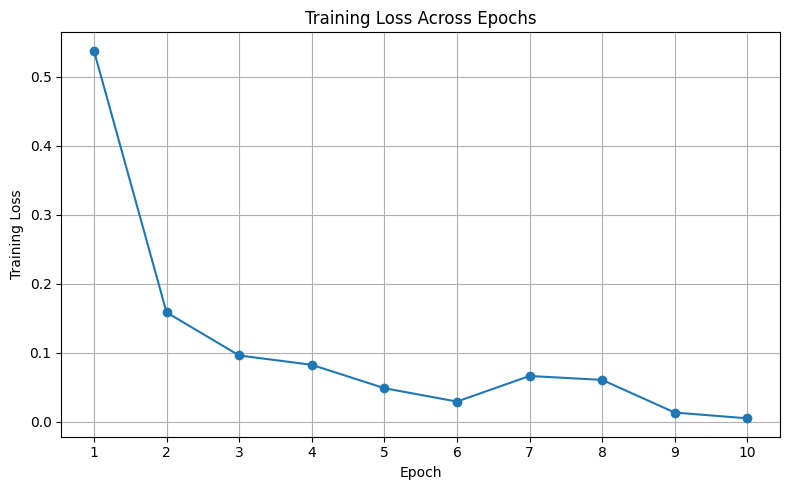

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import models

# ============================================================
# USER SETTINGS
# ============================================================
num_classes = len(train_dataset.classes)
num_epochs = 10          # edit this
learning_rate = 1e-4     # edit this

# Output path for model weights and CSV history
output_dir = "/content/drive/MyDrive/Colab Notebooks/Sheep_Frames_4/2D_CNN_4frame_outputs"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# CLASS WEIGHTS
# ============================================================
class_counts = [0] * num_classes
for _, label in train_dataset.samples:
    class_counts[label] += 1

class_counts_tensor = torch.tensor(class_counts, dtype=torch.float32)
class_weights = class_counts_tensor.sum() / (num_classes * class_counts_tensor)
class_weights = class_weights.to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

# ============================================================
# MODEL
# ============================================================
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# ============================================================
# LOSS AND OPTIMIZER
# ============================================================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ============================================================
# TRAINING LOOP
# ============================================================
history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    history.append({
        "epoch": epoch + 1,
        "train_loss": epoch_loss,
        "train_accuracy": epoch_acc
    })

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.4f}")

print("Training complete.")

# ============================================================
# SAVE TRAINING HISTORY AND MODEL
# ============================================================
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(output_dir, "training_history.csv"), index=False)

model_path = os.path.join(output_dir, "resnet18_4frame.pth")
torch.save(model.state_dict(), model_path)

print("Saved training history to:", os.path.join(output_dir, "training_history.csv"))
print("Saved model to:", model_path)

# ============================================================
# PLOT TRAINING LOSS
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Across Epochs")
plt.xticks(history_df["epoch"])
plt.grid(True)
plt.tight_layout()

# Display the plot inline without saving to disk
plt.show()

I did play with some different number of epoch, but because trainign is so slow on colab I only did 10 and 20 but there was not much if any improvement after 10.

Testing 4 images


Frame-level Test Accuracy: 0.7774

Frame-level Classification Report:
              precision    recall  f1-score   support

     grazing       0.82      0.83      0.83        72
     running       0.61      0.65      0.63        52
     sitting       0.83      0.74      0.78        80
    standing       0.92      1.00      0.96        88
     walking       0.44      0.39      0.41        36

    accuracy                           0.78       328
   macro avg       0.72      0.72      0.72       328
weighted avg       0.77      0.78      0.77       328



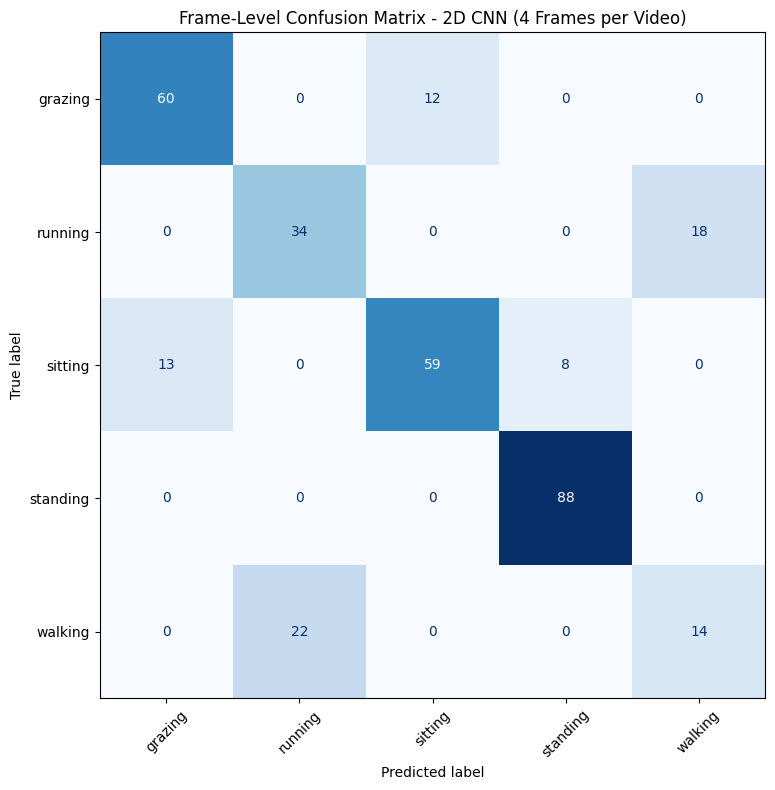


Video-level Test Accuracy (averaged over 4 frames): 0.7683

Video-level Classification Report:
              precision    recall  f1-score   support

     grazing       0.83      0.83      0.83        18
     running       0.57      0.62      0.59        13
     sitting       0.83      0.75      0.79        20
    standing       0.92      1.00      0.96        22
     walking       0.38      0.33      0.35         9

    accuracy                           0.77        82
   macro avg       0.71      0.71      0.70        82
weighted avg       0.76      0.77      0.76        82



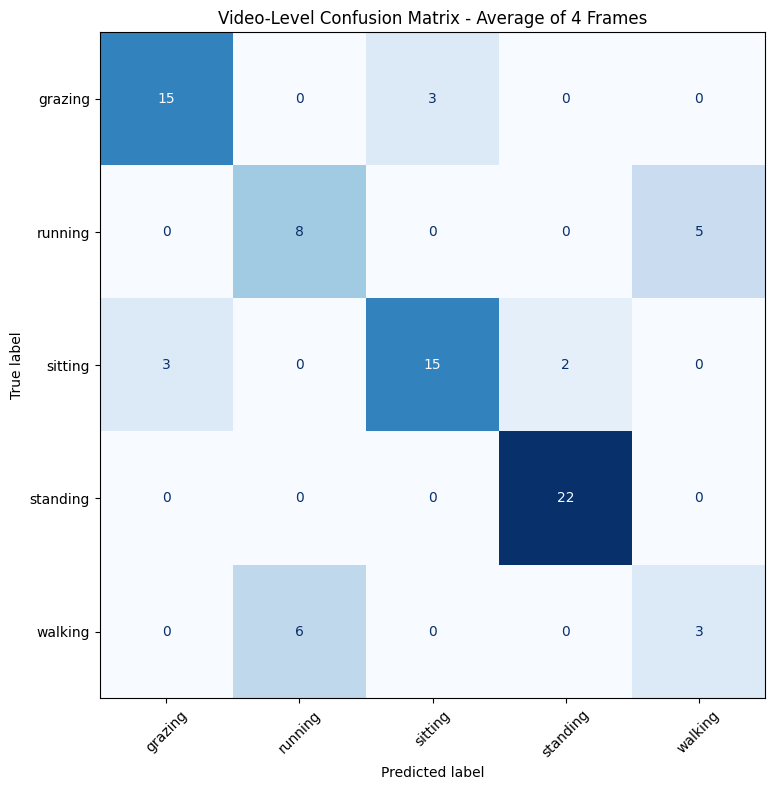


Saved outputs in: /content/drive/MyDrive/Colab Notebooks/Sheep_Frames_4/2D_CNN_4frame_outputs


In [4]:
import os
import re
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ============================================================
# USER SETTINGS
# ============================================================
# Updated output path to Google Drive
output_dir = "/content/drive/MyDrive/Colab Notebooks/Sheep_Frames_4/2D_CNN_4frame_outputs"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# TEST EVALUATION
# Predict every test image and save labels, paths, and probabilities.
# ============================================================
model.eval()

all_preds = []
all_labels = []
all_paths = []
all_probs = []

with torch.no_grad():
    sample_index = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        batch_size_current = labels.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        # Match each prediction to its original image path.
        batch_paths = [test_dataset.samples[sample_index + i][0] for i in range(batch_size_current)]
        all_paths.extend(batch_paths)
        sample_index += batch_size_current

# ============================================================
# FRAME-LEVEL METRICS
# Evaluate predictions for individual frames.
# ============================================================
frame_accuracy = accuracy_score(all_labels, all_preds)
frame_report = classification_report(all_labels, all_preds, target_names=train_dataset.classes)
frame_cm = confusion_matrix(all_labels, all_preds)

print(f"\nFrame-level Test Accuracy: {frame_accuracy:.4f}\n")
print("Frame-level Classification Report:")
print(frame_report)

# Save frame-level text summary.
with open(os.path.join(output_dir, "frame_test_metrics.txt"), "w") as f:
    f.write(f"Frame-level Test Accuracy: {frame_accuracy:.4f}\n\n")
    f.write("Frame-level Classification Report:\n")
    f.write(frame_report)

# Save frame-level confusion matrix values.
frame_cm_df = pd.DataFrame(frame_cm, index=train_dataset.classes, columns=train_dataset.classes)
frame_cm_df.to_csv(os.path.join(output_dir, "frame_confusion_matrix.csv"))

# ============================================================
# SAVE FRAME-LEVEL PREDICTIONS
# One row per test image.
# ============================================================
pred_df = pd.DataFrame({
    "filepath": all_paths,
    "true_label_id": all_labels,
    "pred_label_id": all_preds,
    "true_label_name": [train_dataset.classes[i] for i in all_labels],
    "pred_label_name": [train_dataset.classes[i] for i in all_preds]
})

# Add class probability columns.
prob_array = np.array(all_probs)
for i, class_name in enumerate(train_dataset.classes):
    pred_df[f"prob_{class_name}"] = prob_array[:, i]

pred_df.to_csv(os.path.join(output_dir, "frame_test_predictions.csv"), index=False)

# ============================================================
# PLOT FRAME-LEVEL CONFUSION MATRIX
# ============================================================
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=frame_cm, display_labels=train_dataset.classes)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Frame-Level Confusion Matrix - 2D CNN (4 Frames per Video)")
plt.xticks(rotation=45)
plt.tight_layout()

# Display inline only
plt.show()

# ============================================================
# VIDEO-LEVEL AVERAGING
# Group the 4 frames from each video and average class probabilities.
# ============================================================
def get_video_id(filepath):
    name = os.path.basename(filepath)
    name = os.path.splitext(name)[0]
    name = re.sub(r"_f\d+_idx\d+$", "", name)
    return name

pred_df["video_id"] = pred_df["filepath"].apply(get_video_id)

video_prob_cols = [f"prob_{c}" for c in train_dataset.classes]

video_df = pred_df.groupby("video_id").agg({
    "true_label_id": "first",
    "true_label_name": "first",
    **{col: "mean" for col in video_prob_cols}
}).reset_index()

# Final video prediction = class with highest mean probability.
video_df["pred_label_id"] = video_df[video_prob_cols].values.argmax(axis=1)
video_df["pred_label_name"] = video_df["pred_label_id"].apply(lambda x: train_dataset.classes[x])

video_true = video_df["true_label_id"].tolist()
video_pred = video_df["pred_label_id"].tolist()

# ============================================================
# VIDEO-LEVEL METRICS
# Evaluate one final prediction per video.
# ============================================================
video_accuracy = accuracy_score(video_true, video_pred)
video_report = classification_report(video_true, video_pred, target_names=train_dataset.classes)
video_cm = confusion_matrix(video_true, video_pred)

print(f"\nVideo-level Test Accuracy (averaged over 4 frames): {video_accuracy:.4f}\n")
print("Video-level Classification Report:")
print(video_report)

# Save video-level text summary.
with open(os.path.join(output_dir, "video_test_metrics.txt"), "w") as f:
    f.write(f"Video-level Test Accuracy (averaged over 4 frames): {video_accuracy:.4f}\n\n")
    f.write("Video-level Classification Report:\n")
    f.write(video_report)

# Save video-level confusion matrix values.
video_cm_df = pd.DataFrame(video_cm, index=train_dataset.classes, columns=train_dataset.classes)
video_cm_df.to_csv(os.path.join(output_dir, "video_confusion_matrix.csv"))

# Save one row per video.
video_df.to_csv(os.path.join(output_dir, "video_test_predictions.csv"), index=False)

# ============================================================
# PLOT VIDEO-LEVEL CONFUSION MATRIX
# ============================================================
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=video_cm, display_labels=train_dataset.classes)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Video-Level Confusion Matrix - Average of 4 Frames")
plt.xticks(rotation=45)
plt.tight_layout()

# Display inline only
plt.show()

print("\nSaved outputs in:", output_dir)

The first confusion matrix shows the result testing each of the 4 images randomly sampled for the videos. the second matrix show the result when we average all for as suggested by the assignment. Beacuse some classes where smaller size we show some meaighted performance metrics. Over all ResNet model is doing pretty well for our task. Sampleing and averaging across four images did not yield better restuls than just taking one random image (see below). however there is issue with some of videos. First some videos seem to be missclassified, though i did not change them here, some videos in the grazing video are jsut sheep sitting. I am unsure if this is an error or designed this way. See below for the second issue.

1-frame
set up and loaders

In [5]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ============================================================
# USER SETTINGS
# ============================================================
data_root = "/content/drive/MyDrive/Colab Notebooks/Sheep_Frames_1"
batch_size = 32
num_workers = 2          # Increased for Colab's Linux environment
image_size = 112

# ============================================================
# DEVICE
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ============================================================
# DATASETS
# ============================================================
train_dataset = datasets.ImageFolder(
    root=os.path.join(data_root, "train"),
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(data_root, "test"),
    transform=test_transform
)

# ============================================================
# DATALOADERS
# ============================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

print("Class names:", train_dataset.classes)
print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
Class names: ['grazing', 'running', 'sitting', 'standing', 'walking']
Train images: 327
Test images: 82


1-frame
training

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# ============================================================
# MODEL SETTINGS
# ============================================================
num_classes = len(train_dataset.classes)
num_epochs = 10
learning_rate = 1e-4

# ============================================================
# CLASS WEIGHTS
# ============================================================
class_counts = [0] * num_classes
for _, label in train_dataset.samples:
    class_counts[label] += 1

class_counts_tensor = torch.tensor(class_counts, dtype=torch.float32)
class_weights = class_counts_tensor.sum() / (num_classes * class_counts_tensor)
class_weights = class_weights.to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

# ============================================================
# MODEL
# ============================================================
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# ============================================================
# LOSS AND OPTIMIZER
# ============================================================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ============================================================
# TRAIN LOOP
# ============================================================
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.4f}")

print("Training complete.")

Class counts: [72, 50, 79, 88, 38]
Class weights: tensor([0.9083, 1.3080, 0.8278, 0.7432, 1.7211])
Epoch [1/10] - Loss: 1.1613 - Train Acc: 0.5382
Epoch [2/10] - Loss: 0.3138 - Train Acc: 0.9205
Epoch [3/10] - Loss: 0.1937 - Train Acc: 0.9572
Epoch [4/10] - Loss: 0.1698 - Train Acc: 0.9664
Epoch [5/10] - Loss: 0.1364 - Train Acc: 0.9541
Epoch [6/10] - Loss: 0.0835 - Train Acc: 0.9908
Epoch [7/10] - Loss: 0.1151 - Train Acc: 0.9602
Epoch [8/10] - Loss: 0.1129 - Train Acc: 0.9755
Epoch [9/10] - Loss: 0.0620 - Train Acc: 0.9878
Epoch [10/10] - Loss: 0.0215 - Train Acc: 1.0000
Training complete.


1-frame
testing


Test Accuracy: 0.7561

Classification Report:
              precision    recall  f1-score   support

     grazing       0.75      0.83      0.79        18
     running       0.60      0.69      0.64        13
     sitting       0.81      0.65      0.72        20
    standing       0.92      1.00      0.96        22
     walking       0.43      0.33      0.38         9

    accuracy                           0.76        82
   macro avg       0.70      0.70      0.70        82
weighted avg       0.75      0.76      0.75        82

Saved metrics text file to:
/content/drive/MyDrive/Colab Notebooks/Sheep_Frames_1/2D_CNN_1frame_outputs/test_metrics.txt
Saved confusion matrix CSV to:
/content/drive/MyDrive/Colab Notebooks/Sheep_Frames_1/2D_CNN_1frame_outputs/confusion_matrix.csv
Saved per-image predictions CSV to:
/content/drive/MyDrive/Colab Notebooks/Sheep_Frames_1/2D_CNN_1frame_outputs/test_predictions.csv


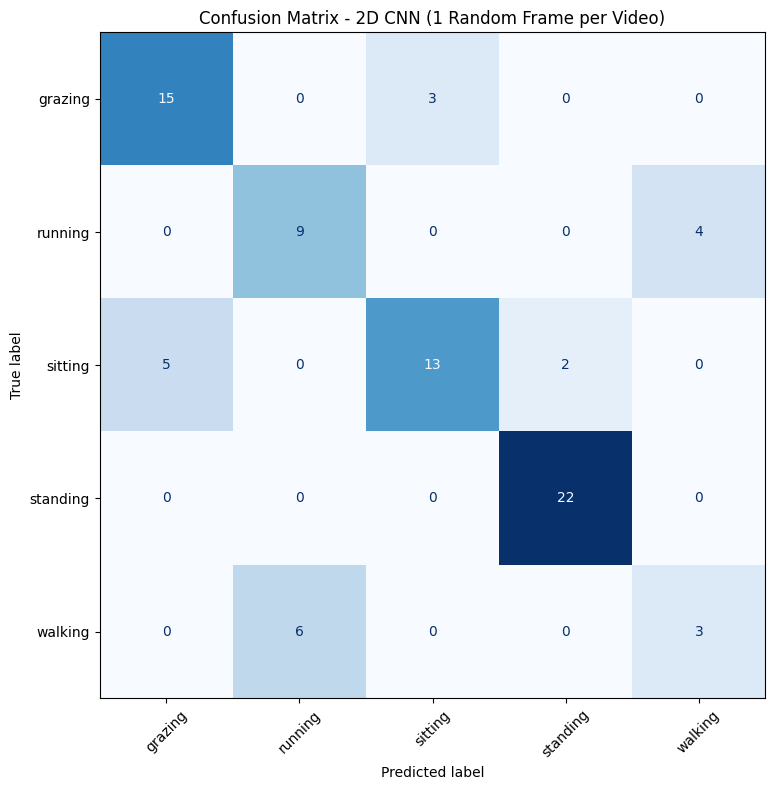

In [7]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ============================================================
# USER SETTINGS
# ============================================================
# Updated output path to Google Drive
output_dir = "/content/drive/MyDrive/Colab Notebooks/Sheep_Frames_1/2D_CNN_1frame_outputs"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# TEST EVALUATION
# ============================================================
model.eval()

all_preds = []
all_labels = []
all_paths = []

with torch.no_grad():
    sample_index = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        batch_size_current = labels.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Get file paths for this batch from ImageFolder samples
        batch_paths = [test_dataset.samples[sample_index + i][0] for i in range(batch_size_current)]
        all_paths.extend(batch_paths)
        sample_index += batch_size_current

# ============================================================
# METRICS
# ============================================================
test_accuracy = accuracy_score(all_labels, all_preds)
report_text = classification_report(all_labels, all_preds, target_names=train_dataset.classes)
cm = confusion_matrix(all_labels, all_preds)

print(f"\nTest Accuracy: {test_accuracy:.4f}\n")
print("Classification Report:")
print(report_text)

# ============================================================
# SAVE METRICS TO TEXT FILE
# ============================================================
metrics_txt_path = os.path.join(output_dir, "test_metrics.txt")

with open(metrics_txt_path, "w") as f:
    f.write(f"Test Accuracy: {test_accuracy:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(report_text)

print("Saved metrics text file to:")
print(metrics_txt_path)

# ============================================================
# SAVE CONFUSION MATRIX VALUES TO CSV
# ============================================================
cm_df = pd.DataFrame(cm, index=train_dataset.classes, columns=train_dataset.classes)
cm_csv_path = os.path.join(output_dir, "confusion_matrix.csv")
cm_df.to_csv(cm_csv_path)

print("Saved confusion matrix CSV to:")
print(cm_csv_path)

# ============================================================
# SAVE PER-IMAGE PREDICTIONS TO CSV
# ============================================================
pred_df = pd.DataFrame({
    "filepath": all_paths,
    "true_label_id": all_labels,
    "pred_label_id": all_preds,
    "true_label_name": [train_dataset.classes[i] for i in all_labels],
    "pred_label_name": [train_dataset.classes[i] for i in all_preds]
})

pred_csv_path = os.path.join(output_dir, "test_predictions.csv")
pred_df.to_csv(pred_csv_path, index=False)

print("Saved per-image predictions CSV to:")
print(pred_csv_path)

# ============================================================
# PLOT CONFUSION MATRIX
# ============================================================
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - 2D CNN (1 Random Frame per Video)")
plt.xticks(rotation=45)
plt.tight_layout()

# Display inline only
plt.show()

The results show that using just one image gave very similar results as the four averaged. Walking and running classification had poorer results but these classed were smaller and when we adjusted for class size using macro and weighted average they were about the same. The second issue with the videos were that not all frames had sheep in them. specifically the running sheep, some videos showed sheep running across the screen but the video did not stop when it left the view of camera. This caused some randomly sampled images to not have any sheep in them. this could be scewing the results as well as the miss classified video.

Macro avg calculates the average metric across classes, giving each class equal weight, no matter how many videos it has.
Weighted avg also averages across classes, but it weights each class by its support, so classes with more videos influence the result more.
